In [236]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pypsa.plot.maps.static import add_legend_circles, add_legend_patches
from IPython.display import display

# Energy Mix
This notebook includes scripts to evaluate the energy mix in different ways:
1) Energy mix by energy source and by country
2) Energy mix by carrier and differences compared to baseline

## 1 - Energy mix by energy source and by country
- energy source type: fossil, renewables, other low-carbon (nuclear and allam)
- interconnections between countries are shown (the blue ones refer to submarine power cables)
- grid scores are shown: RES only includes renewables, CFE includes renewables + other low-carbon (scores = yearly energy share)

In [ ]:
# 0 - functions
def plot_grid_score(n, scenario):
    def load_projection(plotting_params):
        proj_kwargs = plotting_params.get("projection", dict(name="EqualEarth"))
        proj_func = getattr(ccrs, proj_kwargs.pop("name"))
        return proj_func(**proj_kwargs)
    
    def calculate_global_score(n, name, weights):
        name_p = n.buses_t[f"{name}_p"]
        name_all_p = n.buses_t[f"{name}_all_p"]
        
        numerator = (weights @ name_p).sum()
        denominator = (weights @ name_all_p).sum()
        
        return round(numerator / denominator * 100)
    
    # Network copy and constants
    n = network.copy()
    
    bus_size_factor = 1e5
    legend_circles = [100, 50, 30, 10]
    
    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    # Create DataFrame
    df = pd.DataFrame({
        "Renewable sources": weights @ n.buses_t["res_w_ci_p"],
        "Other low-carbon sources": weights @ (n.buses_t["cfe_w_ci_p"] - n.buses_t["res_w_ci_p"]),
        "Fossil sources": weights @ (n.buses_t["cfe_w_ci_all_p"]- n.buses_t["cfe_w_ci_p"])
    })
    
    # Fill missing values and convert to GWh
    df = df.fillna(0).div(1e3)
    
    # Reshape and aggregate
    df.index.name = "bus"
    df = df.reset_index().melt(id_vars=["bus"], value_vars=df.columns, var_name="carrier", value_name="Value")
    df = df.groupby(["bus", "carrier"]).sum()
    df = df.where(df > 1e-4, 0).Value
    
    # Build table by country
    bus_to_country = n.buses["country"].to_dict()
    df_summary = df.reset_index()
    df_summary["country"] = df_summary["bus"].map(bus_to_country)
    df_summary = (df_summary.set_index("country").drop(columns=["bus"]).groupby(["country","carrier"]).sum().unstack()/1e3).round(2) # GWh to TWh
    df_summary.columns = df_summary.columns.droplevel(0)
    df_summary.columns.name = None
    print(f"Gross generation: {round(df_summary.sum().sum(),0)} TWh") 
    print(f"Gross generation by country and by source (TWh)")
    display(df_summary.iloc[0:17, :])
    display(df_summary.iloc[17::, :])

    # Colors for carriers
    colors = {
        "Renewable sources": "#32CD32",
        "Other low-carbon sources": "#adadad",
        "Fossil sources": "#692e0a"
    }
    
    # Projection and plot setup
    proj = load_projection({})
    
    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": proj})
    
    # Bus sizes and link widths
    bus_sizes = df / bus_size_factor
    link_widths = (n.links.carrier == "DC").astype(int)
    
    # Plot network
    n.plot(
        geomap=True,
        bus_sizes=bus_sizes,
        bus_colors=colors,
        line_colors="Black",
        link_colors="Blue",
        link_widths=link_widths,
        branch_components=["Link", "Line"],
        ax=ax,
        boundaries = [-11, 30, 34, 71]
    )
    
    # --- Add Title ---
    ax.set_title(f"{scenario} energy mix in 2030")
    
    # --- Legend schemes ---
    legend_x, legend_y = 1.0, 0.5
    global_cfe_score = calculate_global_score(n, "cfe_w_ci", weights)
    global_res_score = calculate_global_score(n, "res_w_ci", weights)
    description = f"Global Score\nCFE Score: {global_cfe_score}%\nRES Score: {global_res_score}%"
    
    ax.text(
        legend_x + 0.18, legend_y, description, transform=ax.transAxes, verticalalignment='center',horizontalalignment="center",
        bbox=dict(facecolor='white', edgecolor='lightgrey', boxstyle='round,pad=1')
    )
    
    # --- Bus sizes legend ---
    sizes = [s * 1e3 / bus_size_factor for s in legend_circles]
    labels = [f"{s} TWh" for s in legend_circles]
    
    legend_kw = {
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, 1.0),
        "labelspacing": 0.9,
        "handletextpad": 0,
        "frameon": False,
        "title": r"Energy Generation",
    }
    
    add_legend_circles(
        ax,
        sizes,
        labels,
        srid=n.srid,
        patch_kw={"facecolor": "lightgrey"},
        legend_kw=legend_kw,
    )
    
    # --- Carrier patches legend ---
    carriers = df[df > 0].index.get_level_values(1).unique()
    legend_colors = [colors[c] for c in carriers]
    legend_labels = list(carriers)
    
    legend_kw.update({
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, legend_y - 0.25),
        "handletextpad": 0.2,
        "title": r"Energy Type",
        "alignment": "center",
        "ncol": 1
    })
    
    add_legend_patches(
        ax,
        legend_colors,
        legend_labels,
        legend_kw=legend_kw
    )

    fig.savefig(f"energy_mix_by_source_country_{scenario}", dpi=300, bbox_inches="tight")

--------Scenario: baseline-2030-3H--------


INFO:pypsa.io:Imported network baseline-2030-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Final consumption: 3126.0 TWh
System cost: 96.88 bEUR/a
Gross generation: 3256.0 TWh
Gross generation by country and by source (TWh)


,Fossil sources,Other low-carbon sources,Renewable sources
country,,,
AL,0.00,0.00,7.59
AT,5.18,0.00,65.56
BA,0.00,0.00,9.52
BE,6.02,36.43,39.58
BG,1.68,13.23,14.74
CH,0.01,17.89,48.24
CZ,4.65,25.80,15.15
DE,88.35,0.00,456.64
DK,0.69,0.00,83.88


,Fossil sources,Other low-carbon sources,Renewable sources
country,,,
IE,3.02,0.00,28.46
IT,94.93,0.00,196.27
LT,0.47,0.00,13.34
LU,0.00,0.00,1.64
LV,0.78,0.00,5.52
ME,0.00,0.00,3.24
MK,1.36,0.00,3.87
NL,15.58,0.00,99.85
NO,0.03,0.00,136.12


...

INFO:pypsa.io:Imported network baseline-2030-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Final consumption: 3126.0 TWh
System cost: 99.04 bEUR/a
Gross generation: 3257.0 TWh
Gross generation by country and by source (TWh)


,Fossil sources,Other low-carbon sources,Renewable sources
country,,,
AL,0.00,0.00,7.55
AT,5.23,0.00,65.61
BA,0.00,0.00,9.49
BE,6.30,36.21,40.17
BG,1.65,13.27,14.78
CH,0.01,17.82,48.31
CZ,5.16,25.66,15.01
DE,89.32,0.00,458.99
DK,0.69,0.00,82.56


,Fossil sources,Other low-carbon sources,Renewable sources
country,,,
IE,2.80,0.00,27.51
IT,97.82,0.00,195.43
LT,1.16,0.00,13.79
LU,0.00,0.00,1.61
LV,0.58,0.00,5.53
ME,0.00,0.00,3.23
MK,1.34,0.00,3.86
NL,15.46,0.00,99.26
NO,0.03,0.00,136.15


/tmp/ipykernel_5068/637256439.py:71: DeprecatedWarning: plot is deprecated. Use `n.plot.map()` as a drop-in replacement instead.
  n.plot(
/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pypsa/plot/maps/static.py:1678: UserWarning: When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.
  warnings.warn(


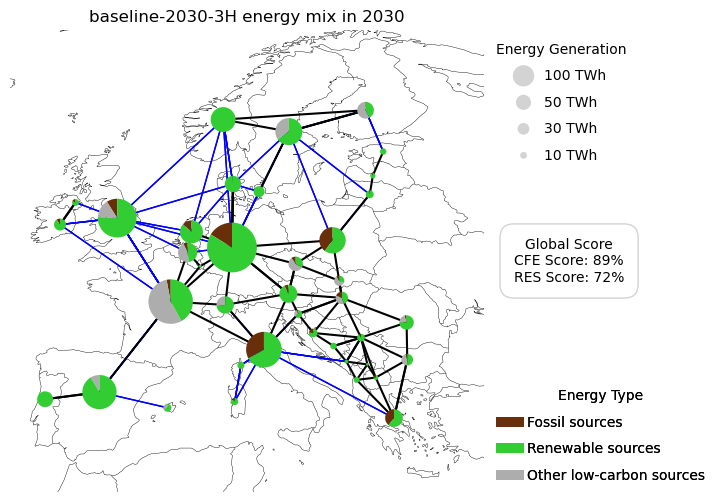

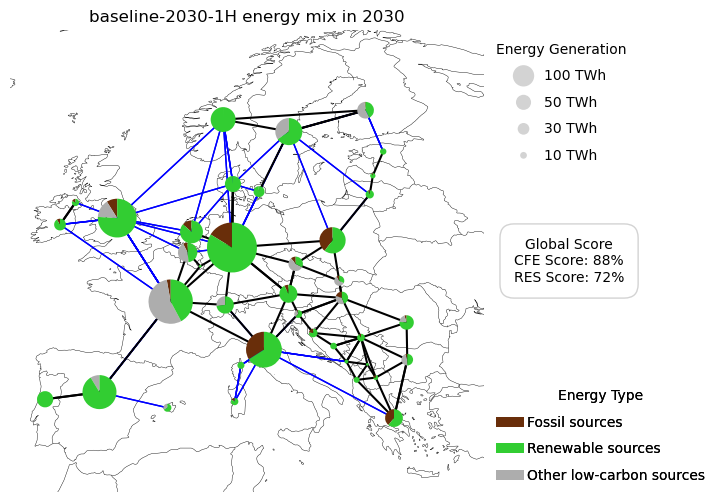

In [227]:
# 1 - Plot energy mix
scenarios = [
    "baseline-2030-3H",
    "baseline-2030-1H",
]

for scenario in scenarios:
    print(f"--------Scenario: {scenario}--------")
    network = pypsa.Network(f"networks/{scenario}.nc")
    load_sum = round((network.snapshot_weightings.generators @ network.loads_t.p).sum() / 1e6, 0) # MWh to TWh
    print(f"Final consumption: {load_sum} TWh")
    system_cost = round(network.objective / 1e9,2)
    print(f"System cost: {system_cost} bEUR/a")
    plot_grid_score(network, scenario)


## 2 - Energy mix by carrier (EU level) and differences compared to baseline

In [1]:
# 0 - functions
carrier_map = {
    "solar rooftop": "Solar-rooftop",
    "solar": "Solar",
    "solar-hsat": "Solar-hsat",
    "onwind": "Wind-onshore",
    "offwind-dc": "Wind-offshore-dc",
    "offwind-ac": "Wind-offshore-ac",
    "offwind-float": "Wind-offshore-float",
    "ror": "Hydro",
    "hydro": "Hydro",
    "geothermal": "Geothermal",
    "OCGT": "Gas",
    "CCGT": "Gas",
    "allam": "Gas with CCS",
    "nuclear": "Nuclear",
    "oil": "Oil",
    "lignite": "Coal",
    "coal": "Coal",
    "urban central gas CHP": "Gas",
    "urban central gas CHP CC": "Gas with CCS",
    "urban central solid biomass CHP": "Biomass",
    "urban central solid biomass CHP CC": "Biomass with CCS",
    "H2 Fuel Cell": "Hydrogen",
    "li-ion battery discharger": "Li-ion battery",
    "li-ion home battery discharger": "Li-ion battery",
    "li-ion battery - CI" : "Li-ion battery"
}

carrier_to_exclude = ["AC",
                      "DC",
                      "electricity distribution grid",
                      "H2 Fuel Cell",
                      "H2 Electrolysis",
                      "li-ion battery charger",
                      "li-ion home battery charger",
                      "PHS",
                      "li-ion battery 8h"]

def get_energy_balance(n, carrier_to_exclude, scenario, display_table=False):
    bus_AC = n.buses.query("carrier == 'AC'").index
    bus_low_voltage = n.buses[n.buses.index.str.contains("low voltage")].index

    df = pd.DataFrame(n.statistics.energy_balance(nice_names = False, comps = ["Generator", "Link", "StorageUnit", "Store"], groupby=["carrier","bus"]))
    df = df.loc[(df.index.get_level_values('bus').isin(bus_AC) | (df.index.get_level_values('bus').isin(bus_low_voltage))) &
                (~df.index.get_level_values('carrier').isin(carrier_to_exclude))
                ]
    df = round(df.groupby(level=[1]).sum()/10**6,2) # MWh to TWh
    df.rename(columns={0: scenario}, inplace=True)

    # Add storage unit output:
    # using p_dispatch instead of n.statistics.energy_balance to be conservative.
    # Indeed, the latter accounts for `p = p_dispatch - p_store`.
    # Also, by using n.statistics.supply (which accounts for p.cip(lower=0))would not be consistent in case p_dispatch and p_store occurs simultaneously.
    sto_i = n.storage_units[n.storage_units.ci != ""].index if "ci" in n.storage_units.columns else []
    sto_unit_output = (n.storage_units_t.p_dispatch[sto_i].multiply(n.snapshot_weightings["generators"], axis=0).sum().sum()/1e6)
    df.loc["li-ion battery - CI"] = sto_unit_output

    print(f"Gross generation (TWh): {round(df[~df.index.isin(['li-ion battery discharger', 'li-ion home battery discharger', 'li-ion battery - CI'])].sum().values[0], 2)}")
    if display_table:
        print(f"Gross generation by carrier (TWh):")
        display(df.style.format("{:.2f}"))
    return df

In [ ]:
# 1 - Process energy balance by carrier
planning_horizon = "2030"
time_resolution = "3"
ci_participation = "25"

scenarios = [f"baseline-{planning_horizon}-{time_resolution}H",
             f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
             f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H",
             f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
             f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H",
             f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H",
             ]

dfs = []

for scenario in scenarios:
    network = pypsa.Network(f"networks/{scenario}.nc")
    print(f"--------Scenario: {scenario}--------")
    df = get_energy_balance(network, carrier_to_exclude, scenario, display_table=False)
    dfs.append(df)

INFO:pypsa.io:Imported network baseline-2030-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


--------Scenario: baseline-2030-3H--------
Gross generation (TWh): 3256.03


INFO:pypsa.io:Imported network vol-match-2030-ci25-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


--------Scenario: vol-match-2030-ci25-3H--------
Gross generation (TWh): 3258.87


INFO:pypsa.io:Imported network vol-match-2030-country-ci25-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


...

--------Scenario: emi-match-2030-ci25-model-mber-3H--------
Gross generation (TWh): 3246.5


INFO:pypsa.io:Imported network emi-match-2030-ci25-model-moer-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


--------Scenario: emi-match-2030-ci25-model-moer-3H--------
Gross generation (TWh): 3257.71


INFO:pypsa.io:Imported network emi-match-2030-ci25-model-cmer-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


--------Scenario: emi-match-2030-ci25-model-cmer-3H--------
Gross generation (TWh): 3256.94


In [230]:
# 2 - Compute differences compared to baseline
df_concat = pd.concat(dfs, axis=1)
df_concat.fillna(0, inplace=True)
df_diff = df_concat.iloc[:, 1:].subtract(df_concat.iloc[:, 0], axis=0)

for scenario in scenarios[1:]:
    total_change = df_diff[scenario].sum()
print("Difference compared to baseline, all carriers included (TWh):\n")
display(round(df_diff.sum(axis=0),2))
print("Difference compared to baseline, carriers contributing less than 1 TWh excluded (TWh):\n")
df_diff = df_diff[abs(df_diff.T.sum()) > 1] # Remove carriers contributing less than +-1 TWh
display(round(df_diff.sum(axis=0),2))

print(f"\nDifference compare to baseline, by carrier, carriers contributing less than 1 TWh excluded (TWh):")
display(df_diff.style.format("{:.2f}"))

Difference compared to baseline, all carriers included (TWh):



vol-match-2030-ci25-3H                11.31
vol-match-2030-country-ci25-3H         0.22
247-cfe-2030-ci25-cfe100-3H          743.06
247-cfe-2030-ci25-cfe90-3H             0.98
emi-match-2030-ci25-model-aer-3H     -11.90
emi-match-2030-ci25-model-mber-3H    -10.87
emi-match-2030-ci25-model-moer-3H      5.37
emi-match-2030-ci25-model-cmer-3H      1.35
dtype: float64

Difference compared to baseline, carriers contributing less than 1 TWh excluded (TWh):



vol-match-2030-ci25-3H                 6.79
vol-match-2030-country-ci25-3H         0.46
247-cfe-2030-ci25-cfe100-3H          766.17
247-cfe-2030-ci25-cfe90-3H            35.17
emi-match-2030-ci25-model-aer-3H     -11.91
emi-match-2030-ci25-model-mber-3H    -45.01
emi-match-2030-ci25-model-moer-3H     -2.52
emi-match-2030-ci25-model-cmer-3H     -8.96
dtype: float64


Difference compare to baseline, by carrier, carriers contributing less than 1 TWh excluded (TWh):


,vol-match-2030-ci25-3H,vol-match-2030-country-ci25-3H,247-cfe-2030-ci25-cfe100-3H,247-cfe-2030-ci25-cfe90-3H,emi-match-2030-ci25-model-aer-3H,emi-match-2030-ci25-model-mber-3H,emi-match-2030-ci25-model-moer-3H,emi-match-2030-ci25-model-cmer-3H
carrier,,,,,,,,
CCGT,0.61,8.00,-46.81,-58.74,-24.94,-17.07,0.74,0.98
coal,0.17,-5.46,2.93,-5.76,-11.19,-0.55,0.26,0.19
li-ion battery discharger,0.62,-0.83,-9.42,-9.42,-1.46,-1.26,-0.26,-0.79
li-ion home battery discharger,7.85,0.47,-31.40,-23.54,-1.42,-0.08,3.95,1.23
lignite,0.01,-0.03,-0.89,-0.93,-0.20,-0.10,0.01,0.02
nuclear,0.01,-2.34,51.06,33.12,-0.08,-1.65,-0.54,-0.94
offwind-ac,-5.98,-0.29,133.53,127.88,9.41,-10.58,-0.42,-2.90
offwind-dc,-6.26,1.50,19.14,87.19,52.43,-3.09,-7.19,8.15
offwind-float,0.00,0.00,7.41,1.15,0.00,0.00,0.00,0.00


In [231]:
# 2.1 - Aggregate by carrier_map and prepare color plot
df_color = pd.Series(
        [n.carriers.color.get(c) or "#000000" for c in df_diff.index],
        index=df_diff.index,
        name="color"
    )
df_color.rename(index=carrier_map, inplace=True)
df_color = df_color[~df_color.index.duplicated(keep='first')]
df_color.sort_index(inplace=True) # to align with df_new, since df_new.index is sorted after we rename the index
df_color["Li-ion battery"] = "#000000" 
df_new = df_diff.rename(index=carrier_map)
df_new = df_new.groupby(level=0).sum()
df_color

carrier
Coal                   #545454
Gas                    #a85522
Hydro                  #3dbfb0
Li-ion battery         #000000
Nuclear                #ff8c00
Solar                  #f9d002
Solar-rooftop          #ffea80
Wind-offshore-ac       #6895dd
Wind-offshore-dc       #74c6f2
Wind-offshore-float    #b5e2fa
Wind-onshore           #235ebc
Name: color, dtype: object

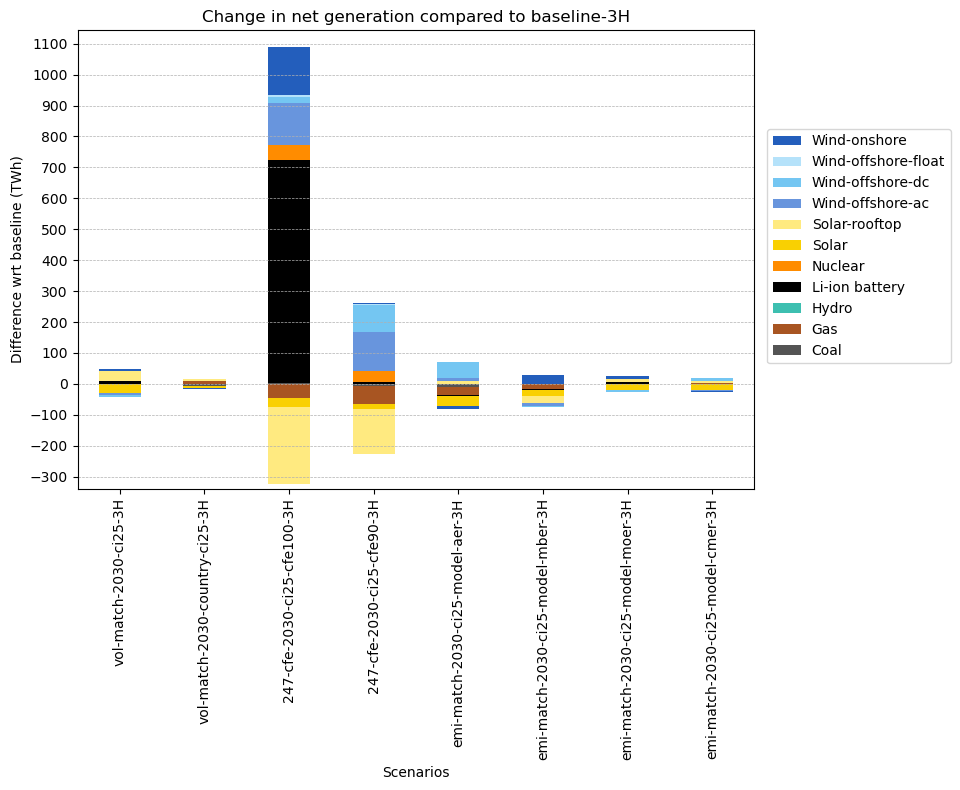

In [ ]:
# 2.2 - Plot differences compared to baseline by carrier and scenario
fig, ax = plt.subplots(figsize=(10, 10))

df_new.T.plot(ax=ax, kind='bar', color=df_color, figsize=(10, 8), stacked=True)
plt.title(f"Change in net generation compared to baseline-{time_resolution}H")
plt.xlabel("Scenarios")
plt.ylabel("Difference wrt baseline (TWh)")
ymin = df_new[df_new < 0].sum().min()
ymax = df_new[df_new > 0].sum().max()
plt.ylim([1.05*ymin, 1.05*ymax])
if ymax > 500:
    ymult = 100
elif 100 < ymax <= 500:
    ymult = 50
elif 25 < ymax <= 100:
    ymult = 25
else:
    ymult = 10
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(ymult))
plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.3, 0.8))
plt.tight_layout()
plt.show()

fig.savefig(f"differences_wrt_baseline-{planning_horizon}-{ci_participation}-{time_resolution}H", dpi=300, bbox_inches="tight")

In [233]:
# 3 - Process results for energy mix
df_concat = pd.concat(dfs, axis=1)
df_concat.fillna(0, inplace=True)

# Separete carriers below the threshold of 1% of total gross generation into "Others"
thresholds = df_concat.sum(axis=0) * 0.01
other_carriers = {}
df_mod = df_concat.copy()

for col in df_mod.columns:
    mask = df_mod[col] < thresholds[col]
    other_carriers[col] = df_mod.index[mask].tolist()
    df_mod.loc[mask, col] = np.nan

other_row = {}
for col in df_mod.columns:
    carriers_to_sum = [c for c in other_carriers[col] if "battery" not in c]
    other_row[col] = df_concat.loc[carriers_to_sum, col].sum() if carriers_to_sum else np.nan

df_mod.loc["Others"] = other_row

df_mod = df_mod.dropna(how='all')

In [234]:
# 3.1 - Aggregate by carrier_map and prepare color plot
df_color_mix = pd.Series(
            [n.carriers.color.get(c) or "#000000" for c in df_mod.index],
            index=df_mod.index,
            name="color"
        )
df_color_mix.rename(index=carrier_map, inplace=True)
df_color_mix = df_color_mix[~df_color_mix.index.duplicated(keep='first')]
df_color_mix.sort_index(inplace=True) # to align with df_new, since df_new.index is sorted after we rename the index
df_color_mix.loc["Li-ion battery"] = "#000000" 
df_color_mix_mod = df_color_mix.drop("Li-ion battery", errors="ignore")
df_color_mix_mod.loc["Others"] = "#00000051" 

df_concat.rename(index=carrier_map, inplace=True)
df_concat = df_concat.groupby(level=0).sum()

df_mod_new = df_mod.rename(index=carrier_map)
df_mod_new = df_mod_new.groupby(level=0).sum()
df_mod_new = df_mod_new.drop("Li-ion battery", axis=0)

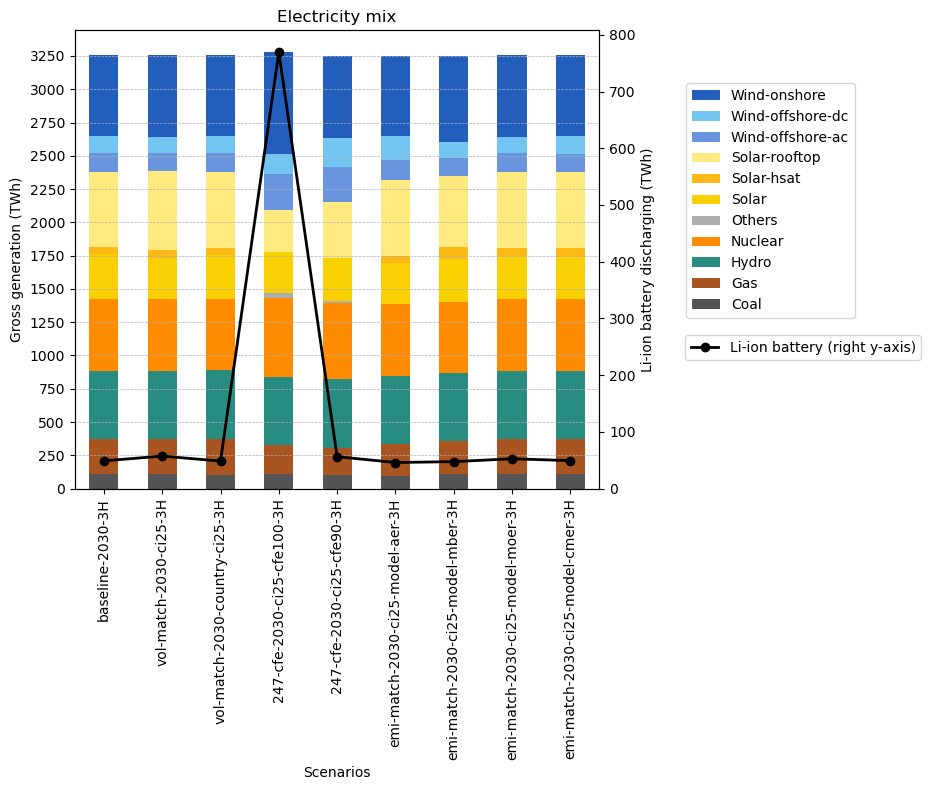

In [ ]:
# 3.2 - Plot the energy mix by carrier and scenario
fig, ax = plt.subplots(figsize=(7, 6))

df_mod_new.T.plot(ax=ax, kind='bar', color=df_color_mix_mod, figsize=(10, 8), stacked=True)
ax.set_xlabel("Scenarios")
ax.set_ylabel("Gross generation (TWh)")
ymax = df_mod_new.sum().max()
ax.set_ylim([0,1.05*ymax])
if ymax > 500:
    ymult = 250
elif 100 < ymax <= 500:
    ymult = 100
elif 25 < ymax <= 100:
    ymult = 25
else:
    ymult = 10
ax.yaxis.set_major_locator(plt.MultipleLocator(ymult))
ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5)

# Invert the order of the legend labels
ax.legend(bbox_to_anchor=(1.15, 1), )
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.5, 0.9))

# Li-ion battery discharging
ax2 = ax.twinx()
df_concat.T.loc[:, "Li-ion battery"].plot(ax=ax2, kind='line', color='k', linewidth=2, marker='o', label="Li-ion battery (right y-axis)")
ax2.set_ylabel("Li-ion battery discharging (TWh)")

ymin = df_concat.T.loc[:, "Li-ion battery"].min()
ymax = df_concat.T.loc[:, "Li-ion battery"].max()
ax2.set_ylim([0*ymin, 1.05*ymax])

ax2.legend(bbox_to_anchor=(1.15, 0.35), loc='upper left')

# save
plt.title("Electricity mix")
plt.tight_layout()
plt.show()
fig.savefig(f"energy_mix_by_carrier_scenario-{planning_horizon}-{ci_participation}-{time_resolution}H", dpi=300, bbox_inches="tight")